# Projeto Final de Machine Learning - Classificação de Câncer de Pele 

## Configurações de Ambiente

O objetivo desta seção é preparar o ambiente com as configurações necessárias para executar o projeto.

---


### Dependências 

#### Python e configuração básica

In [1]:
import os
import shutil
import random
os.environ["KAGGLE_CONFIG_DIR"] = "."

#### Modelagem de Dados

In [3]:
import numpy as np
import pandas as pd

#### Visualização de dados

In [4]:
from PIL import Image
import matplotlib.patches as patches
import seaborn as sns
import matplotlib.pyplot as plt

#### Machine Learning

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import label_binarize
from tensorflow.keras.utils import to_categorical

#### Kaggle

In [10]:
# Configuração da API do Kaggle
from kaggle.api.kaggle_api_extended import KaggleApi

---

### Variáveis Globais

#### Variáveis de diretório

In [11]:
DATA_DIR = "data"
DATASET_NAME = "kmader/skin-cancer-mnist-ham10000"
src_dirs = [os.path.join(DATA_DIR, "HAM10000_images_part_1"), os.path.join(DATA_DIR, "HAM10000_images_part_2")]
dst_dir = os.path.join(DATA_DIR, "HAM10000_images")
METADATA_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
IMAGES_DIR = os.path.join(DATA_DIR, "HAM10000_images")

Definiu-se:

- `DATA_DIR`: diretório base onde todos os dados do projeto serão armazenados (`data`);
- `DATASET_NAME`: identificador do dataset no Kaggle (`kmader/skin-cancer-mnist-ham10000`);
- `src_dirs`: lista com os diretórios originais das imagens (`HAM10000_images_part_1` e `HAM10000_images_part_2`);
- `dst_dir`: diretório final onde todas as imagens serão consolidadas (`HAM10000_images`);
- `METADATA_PATH`: caminho completo para o arquivo `HAM10000_metadata.csv`;
- `IMAGES_DIR`: caminho para o diretório que contém todas as imagens utilizadas pelo modelo.

#### Variáveis de Classes

In [12]:
# Dicionário de classes
class_names = {
    'nv': 'Nevos melanocíticos',
    'mel': 'Melanoma',
    'bkl': 'Queratose benigna',
    'bcc': 'Carcinoma basocelular',
    'akiec': 'Queratose actínica',
    'vasc': 'Lesões vasculares',
    'df': 'Dermatofibroma'
}
num_classes = len(class_names)

Definiu-se: 
- `class_names`: dicionário que mapeia os códigos do diagnóstico (`dx`) para nomes descritivos em português.

#### Variáveis das Imagens

In [13]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3

Definiu-se:

- `IMG_HEIGHT`: altura para a qual todas as imagens serão redimensionadas (128 pixels).
- `IMG_WIDTH`: largura usada no redimensionamento das imagens (128 pixels).
- `CHANNELS`: número de canais de cor; usamos 3 para imagens RGB.

#### Variáveis de ML

In [14]:
# Seed para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# Tamanho do batch para treinamento
BATCH_SIZE = 32
# Número de épocas para treinamento
EPOCHS = 30

# Proporções de validação e teste em relação ao total
VAL_SIZE = 0.15   # 15% para validação
TEST_SIZE = 0.15  # 15% para teste
AUTOTUNE = tf.data.AUTOTUNE

Definiu-se:


- `SEED`: semente global usada para sincronizar todos os geradores pseudoaleatórios.  
  Aplicada em:
  - `random.seed(SEED)`  
  - `np.random.seed(SEED)`  
  - `tf.random.set_seed(SEED)`  
  Isso reduz variação nos splits, inicializações de pesos e operações aleatórias.
- `BATCH_SIZE`: número de imagens processadas antes de cada atualização de gradiente  
  (define o tamanho do batch).
- `EPOCHS`: quantidade de ciclos completos de treinamento sobre o dataset.
- `VAL_SIZE`: porcentagem reservada para validação (15%).  
- `TEST_SIZE`: porcentagem reservada para teste final (15%).
- `AUTOTUNE`: Permite que o TensorFlow ajuste automaticamente o grau de paralelismo ao processar o dataset.

---

### Carregamento de Dados

#### Download via Kaggle

Baixe o seu token no site do kaggle e adicione o arquivo `kaggle.json` na raiz do projeto.

In [15]:
# Diretório para salvar os dados
os.makedirs(DATA_DIR, exist_ok=True)

# Autenticação na API do Kaggle
api = KaggleApi()
api.authenticate()

# Download do dataset
print("Baixando dataset...")
api.dataset_download_files(DATASET_NAME, path=DATA_DIR, unzip=True)
print("✅ Download e extração concluídos!")

Baixando dataset...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
✅ Download e extração concluídos!


#### Organização das imagens em um diretório único

Após o download, as imagens do HAM10000 vêm separadas em duas pastas: `HAM10000_images_part_1` e `HAM10000_images_part_2`. Para simplificar o acesso, o conteúdo das pastas foi concatenado em um único diretório.

In [16]:
# Criar diretório final se não existir
os.makedirs(dst_dir, exist_ok=True)

for src in src_dirs:
    for filename in os.listdir(src):
        src_path = os.path.join(src, filename)
        dst_path = os.path.join(dst_dir, filename)

        # Move apenas arquivos
        if os.path.isfile(src_path):
            shutil.move(src_path, dst_path)

    # Após mover tudo, remover pasta antiga
    shutil.rmtree(src)

print(f"Imagens movidas para /{dst_dir} e diretórios antigos removidos!")

Imagens movidas para /data\HAM10000_images e diretórios antigos removidos!


---

## Análise Exploratória do Dataset

O objetivo desta seção é entender o conjunto de dados **HAM10000** e seus metadados (idade, sexo e localização anatômica) antes de treinar os modelos.  

---


### 1. Visão geral do dataset

O dataset **HAM10000** contém sete tipos de lesões cutâneas pigmentadas.
Cada amostra possui:

- uma imagem dermatoscópica;
- um registro de metadados (idade, sexo, localização anatômica etc.).

As classes presentes são:

- **Melanocytic nevi (`nv`)** – nevos melanocíticos benignos;
- **Melanoma (`mel`)** – melanoma maligno;
- **Benign keratosis (`bkl`)** – queratoses benignas;
- **Basal cell carcinoma (`bcc`)** – carcinoma basocelular;
- **Actinic keratoses (`akiec`)** – queratose actínica;
- **Dermatofibroma (`df`)** – dermatofibroma;
- **Vascular lesions (`vasc`)** – lesões vasculares.

---


### 2. Metadados

#### 2.1 Estrutura e qualidade dos dados

In [17]:
# Lê arquivo de METADATA
metadata_df = pd.read_csv(METADATA_PATH)
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [18]:
metadata_df[["dx", "sex", "localization", "dx_type"]].describe()

,dx,sex,localization,dx_type
count,10015,10015,10015,10015
unique,7,3,15,4
top,nv,male,back,histo
freq,6705,5406,2192,5340


In [19]:
metadata_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


O dataframe utilizado possui **10.015 linhas**, cada uma representando uma lesão, com colunas como:

- `image_id`: identificador único da imagem;
- `lesion_id`: identificador da lesão (podem existir múltiplas imagens da mesma lesão);
- `dx`: classe diagnosticada [7 tipos de classe diferentes] (`bkl`, `nv`, ...);
- `dx_type`: tipo de confirmação diagnóstica [4 tipos diferentes](`histopatologia`, `acompanhamento`, ...);
- `age`: idade do paciente;
- `sex`: sexo do paciente [3 classificações](`male`, `female` ou `unknown`);
- `localization`: localização anatômica da lesão [15 locais diferentes] (`face`, `peito`, ...).

Apenas o atributo **`age`** apresenta valores ausentes: 70 registros (~0,7% do total) não possuem idade informada.  

---

#### 2.2 Enriquecimento do dataframe

In [20]:
# Cria image_path a partir do image_id
metadata_df["image_path"] = metadata_df["image_id"].apply(
    lambda x: os.path.join(IMAGES_DIR, f"{x}.jpg")
)

# Mantém apenas registros com imagens existentes
metadata_df = metadata_df[metadata_df["image_path"].apply(os.path.exists)].reset_index(drop=True)

In [21]:
# Adicionar nome amigável e índice numérico
metadata_df['class_name'] = metadata_df['dx'].map(class_names)
metadata_df['class_idx'] = pd.Categorical(metadata_df['dx']).codes

Para facilitar o uso do dataset nas demais etapas do projeto, foram adicionadas ao dataframe novas colunas:

- **`image_path`** – caminho completo até o arquivo `.jpg` a partir de `image_id`, o que simplifica o carregamento das imagens;
- **`class_name`** – nome descritivo da classe, obtido mapeando o código `dx` para um rótulo legível (por exemplo, `nv` → *Nevos melanocíticos*);
- **`class_idx`** – rótulo numérico (0–6) associado a cada classe, usado como alvo nos modelos de classificação.

Além disso, o dataframe foi filtrado para manter apenas as linhas cujas imagens realmente existem no diretório de imagens, garantindo consistência entre os metadados e os arquivos presentes em disco.


In [22]:
print(f"Total de imagens mantidas: {len(metadata_df)}")
print("Dataset atualizado:")
metadata_df.head()

Total de imagens mantidas: 10015
Dataset atualizado:


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,class_name,class_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0027419.jpg,Queratose benigna,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0025030.jpg,Queratose benigna,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0026769.jpg,Queratose benigna,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0025661.jpg,Queratose benigna,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,data\HAM10000_images\ISIC_0031633.jpg,Queratose benigna,2


---

### 3. Distribuição das classes

In [23]:
print("Mapeamento de classes:")
for idx, (code, name) in enumerate(class_names.items()):
    count = (metadata_df['dx'] == code).sum()
    print(f"  {idx}: {code:6s} -> {name:30s} ({count:4d} imagens)")

Mapeamento de classes:
  0: nv     -> Nevos melanocíticos            (6705 imagens)
  1: mel    -> Melanoma                       (1113 imagens)
  2: bkl    -> Queratose benigna              (1099 imagens)
  3: bcc    -> Carcinoma basocelular          ( 514 imagens)
  4: akiec  -> Queratose actínica             ( 327 imagens)
  5: vasc   -> Lesões vasculares              ( 142 imagens)
  6: df     -> Dermatofibroma                 ( 115 imagens)


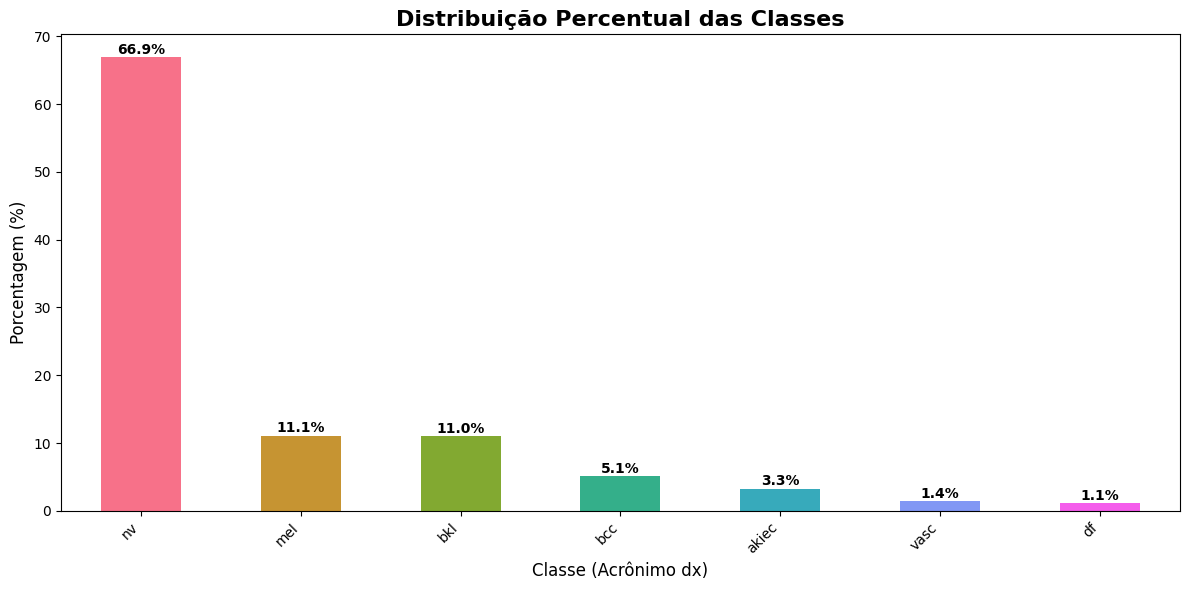

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Count by class using acronym (dx)
class_counts = metadata_df['dx'].value_counts()

# Convert to percentage
class_percent = (class_counts / class_counts.sum()) * 100

# Plot
class_percent.plot(kind='bar', ax=ax, color=sns.color_palette("husl", len(class_percent)))

ax.set_title('Distribuição Percentual das Classes', fontsize=16, fontweight='bold')
ax.set_xlabel('Classe (Acrônimo dx)', fontsize=12)
ax.set_ylabel('Porcentagem (%)', fontsize=12)
ax.set_xticklabels(class_percent.index, rotation=45, ha='right')

# Add percentage labels above bars
for i, v in enumerate(class_percent.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()   

Usando a coluna `dx`, foi calculada a contagem de imagens por classe e suas porcentagens.  
O gráfico de barras resultante mostra que o dataset é **fortemente desbalanceado**:

- a classe **`nv`** (nevos melanocíticos) concentra **mais da metade das imagens**;
- classes como **`df`** e **`vasc`** possuem pouco mais de uma centena de exemplos;
- as demais classes (**`akiec`**, **`bcc`**, **`bkl`**, **`mel`**) aparecem em quantidades intermediárias.

Esse desbalanceamento é problemático porque um modelo pode obter alta acurácia apenas “chutando” a classe majoritária.  

---

### 4. Distribuições globais dos metadados

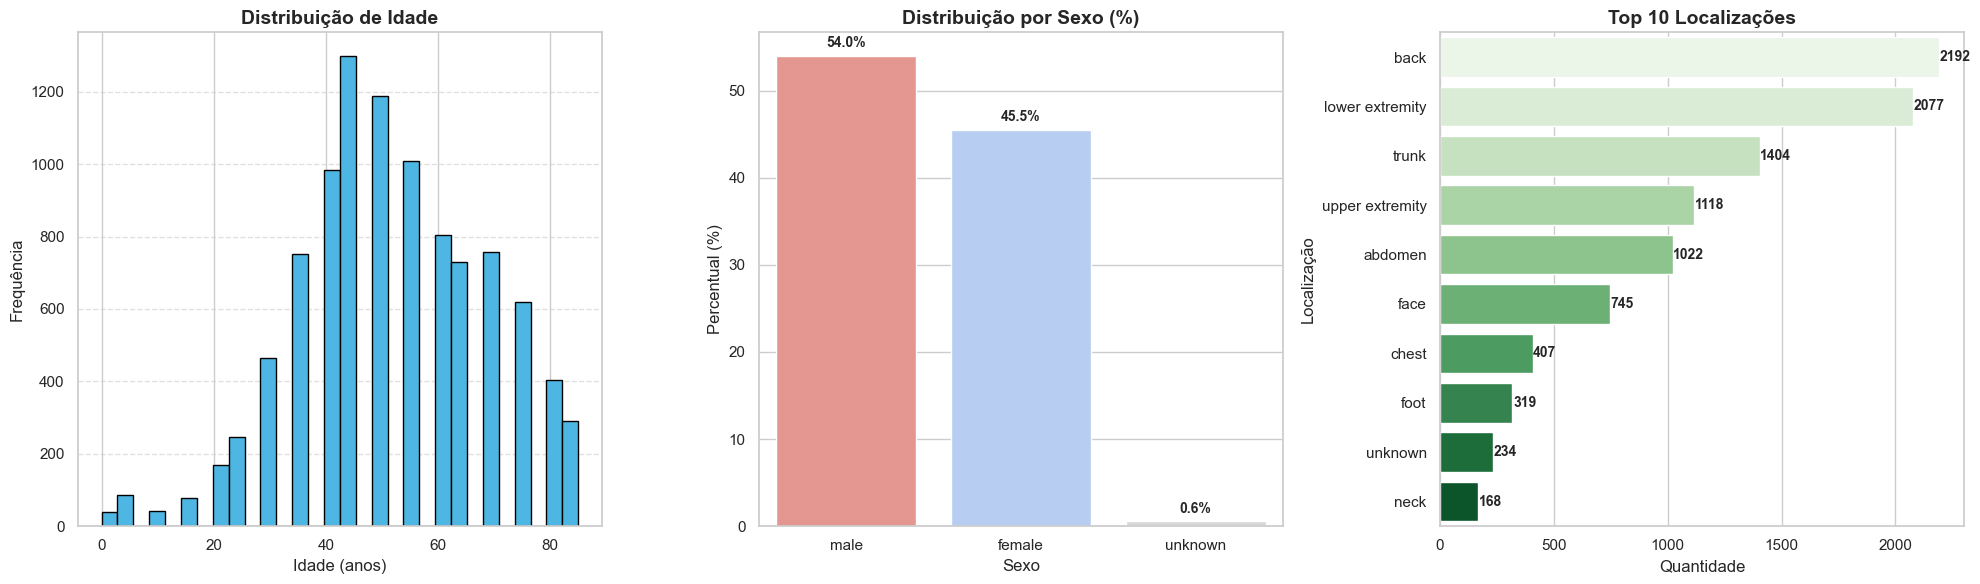

In [25]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# =========================================
# 1) Distribuição de Idade
# =========================================
axes[0].hist(metadata_df['age'].dropna(), bins=30, color='#4DB6E2', edgecolor='black')
axes[0].set_title('Distribuição de Idade', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Frequência')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)



# =========================================
# 2) Distribuição por Sexo (em %)
# =========================================
sex_percent = metadata_df['sex'].value_counts(normalize=True) * 100
sex_df = sex_percent.reset_index()
sex_df.columns = ['sex', 'percent']

sns.barplot(
    data=sex_df,
    x='sex',
    y='percent',
    hue='sex',           
    palette=['#F28B82', '#AECBFA', '#D7D7D7'],
    legend=False,            
    ax=axes[1]
)

axes[1].set_title('Distribuição por Sexo (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Percentual (%)')
plt.setp(axes[1].get_xticklabels(), rotation=0)


# value labels
for i, v in enumerate(sex_percent.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10, fontweight='bold')



# =========================================
# 3) Top 10 Localizações
# =========================================
top_loc = metadata_df['localization'].value_counts().head(10)
loc_df = top_loc.reset_index()
loc_df.columns = ['localization', 'count']

sns.barplot(
    data=loc_df,
    x='count',
    y='localization',
    hue='localization',   
    palette='Greens',
    legend=False,          
    ax=axes[2]
)

axes[2].set_title('Top 10 Localizações', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Quantidade')
axes[2].set_ylabel('Localização')

# labels
for i, v in enumerate(top_loc.values):
    axes[2].text(v + 3, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


Nesta etapa foi analisado a distribuição de **idade**, **sexo** e **localização anatômica** considerando todas as classes juntas.

- **Idade**  
  O histograma de `age` mostra idades aproximadamente entre 0 e 85 anos, com maior concentração em adultos de meia-idade e idosos.  
  Isso está de acordo com o comportamento esperado para doenças de pele, que tendem a ser mais frequentes em faixas etárias mais altas.

- **Sexo**  
  A variável `sex` é relativamente **balanceada** entre masculino e feminino, com leve predominância do sexo masculino e uma pequena fração de registros com sexo desconhecido.  
  Esse desbalanceamento leve não é crítico, mas vale ser monitorado caso os metadados sejam usados diretamente como entrada do modelo.

- **Localização anatômica**  
  A coluna `localization` é bastante **desigual**: regiões como *back*, *lower extremity* e *trunk* aparecem com muito mais frequência do que regiões raras como *ear*, *genital* ou *acral*.  
  Isso indica que o modelo pode ter mais dificuldade para generalizar bem em localizações pouco representadas.
---

### 5. Distribuições por classe (metadados condicionados ao diagnóstico)

In [26]:
def plot_demographics_for_class(df, class_code, class_label=None, n_top_loc=10):
    subset = df[df["dx"] == class_code]

    if subset.empty:
        print(f"⚠️ No samples for class '{class_code}'")
        return

    if class_label is None:
        class_label = class_code

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Demographic distribution for class: {class_label} ({class_code})",
        fontsize=16, fontweight="bold", y=1.02
    )

    # 1) Age distribution
    axes[0].hist(subset["age"].dropna(), bins=20, color="#4DB6E2", edgecolor="black")
    axes[0].set_title("Age distribution", fontweight="bold")
    axes[0].set_xlabel("Age (years)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.6)

    # 2) Sex distribution (in %)
    sex_percent = subset["sex"].value_counts(normalize=True) * 100
    sex_df = sex_percent.reset_index()
    sex_df.columns = ["sex", "percent"]
    base_colors = ["#F28B82", "#AECBFA", "#D7D7D7"]
    palette = base_colors[:len(sex_df)]

    sns.barplot(
        data=sex_df,
        x="sex",
        y="percent",
        hue="sex",         
        palette=palette,
        legend=False,
        ax=axes[1]
    )
    axes[1].set_title("Sex distribution (%)", fontweight="bold")
    axes[1].set_xlabel("Sex")
    axes[1].set_ylabel("Percentage (%)")
    plt.setp(axes[1].get_xticklabels(), rotation=0)

    for i, v in enumerate(sex_df["percent"]):
        axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

    # 3) Top locations (counts)
    top_loc = subset["localization"].value_counts().head(n_top_loc)
    loc_df = top_loc.reset_index()
    loc_df.columns = ["localization", "count"]

    sns.barplot(
        data=loc_df,
        x="count",
        y="localization",
        hue="localization",
        palette="Greens",
        legend=False,
        ax=axes[2]
    )
    axes[2].set_title("Top locations", fontweight="bold")
    axes[2].set_xlabel("Count")
    axes[2].set_ylabel("Location")

    for i, v in enumerate(loc_df["count"]):
        axes[2].text(v + 0.5, i, str(v), va="center", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.show()

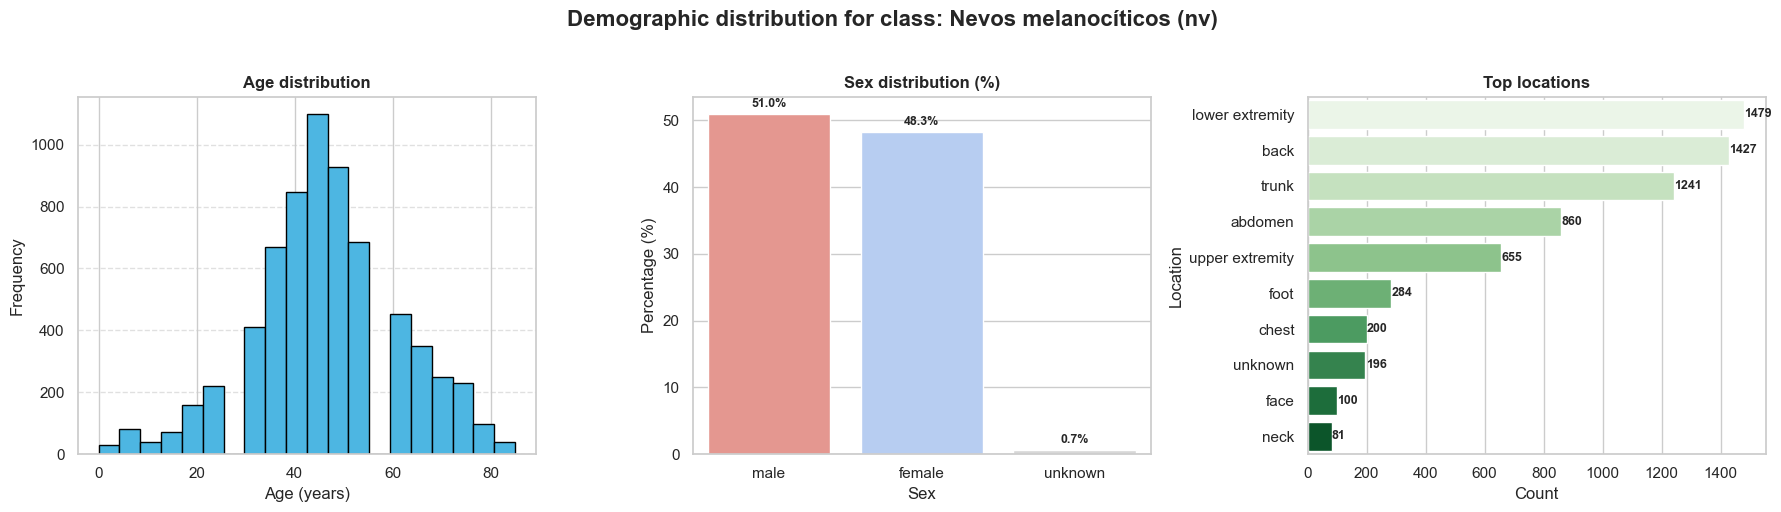

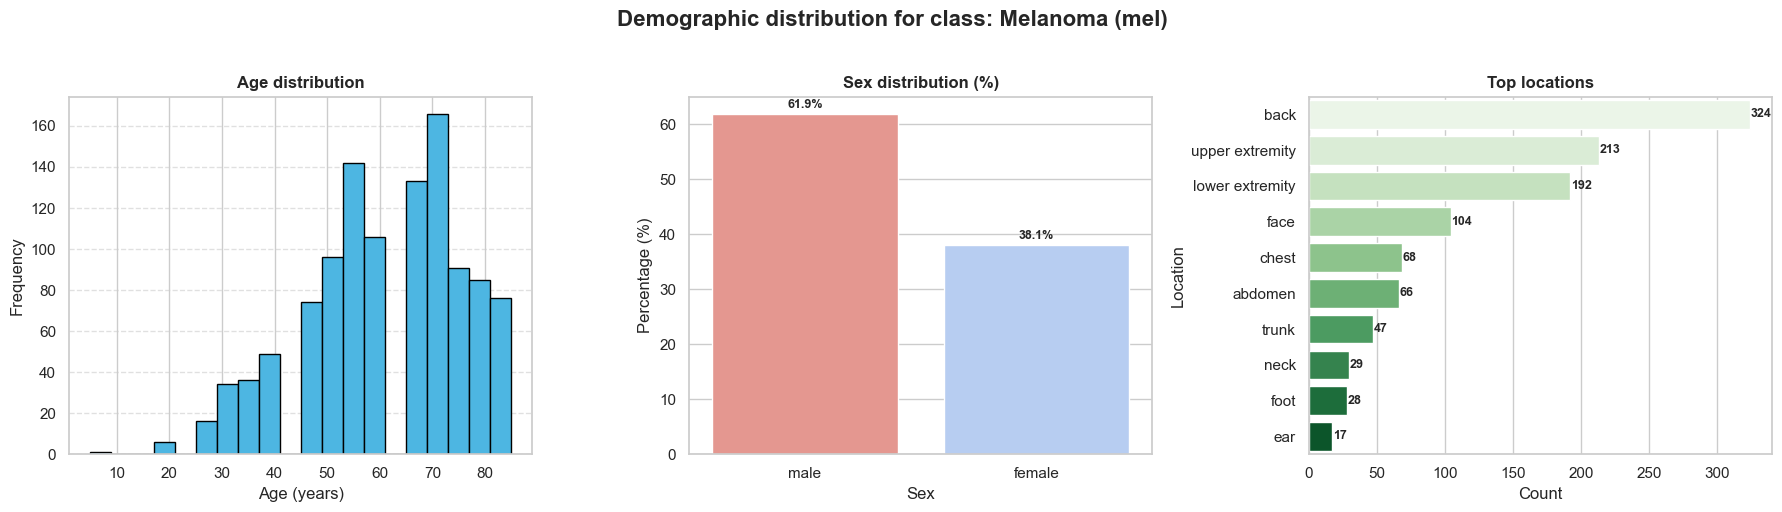

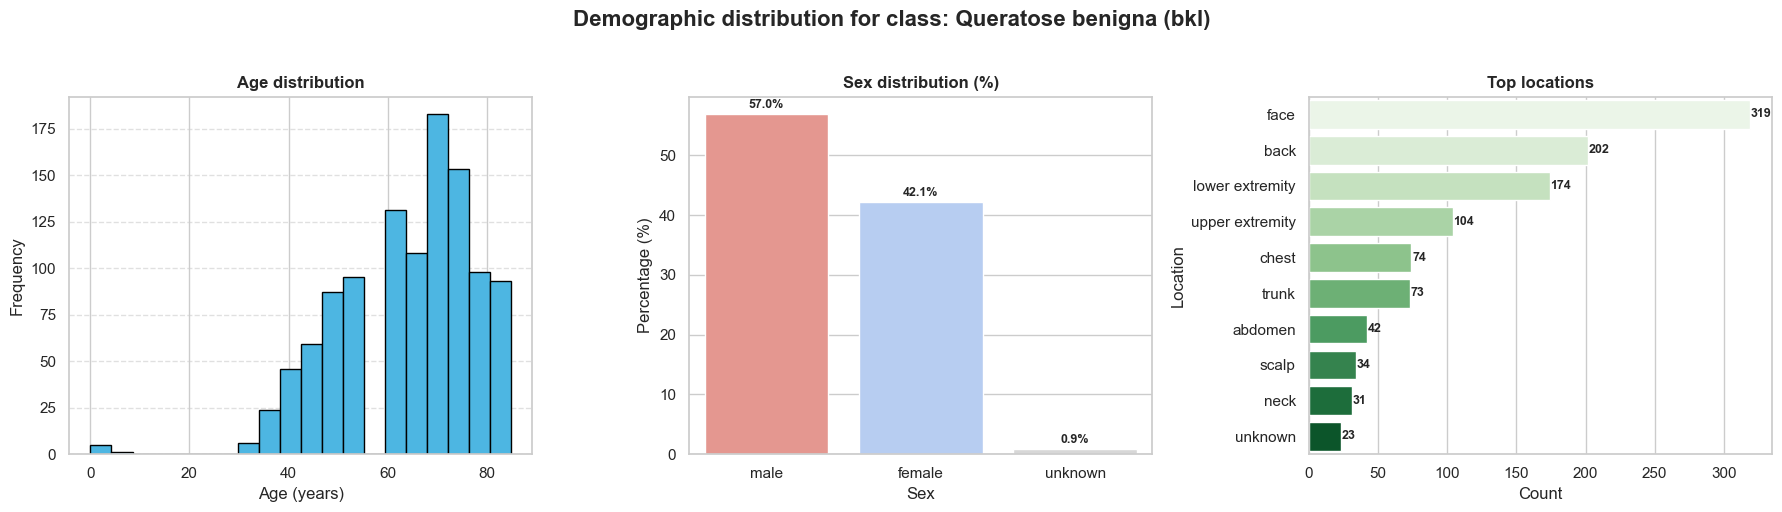

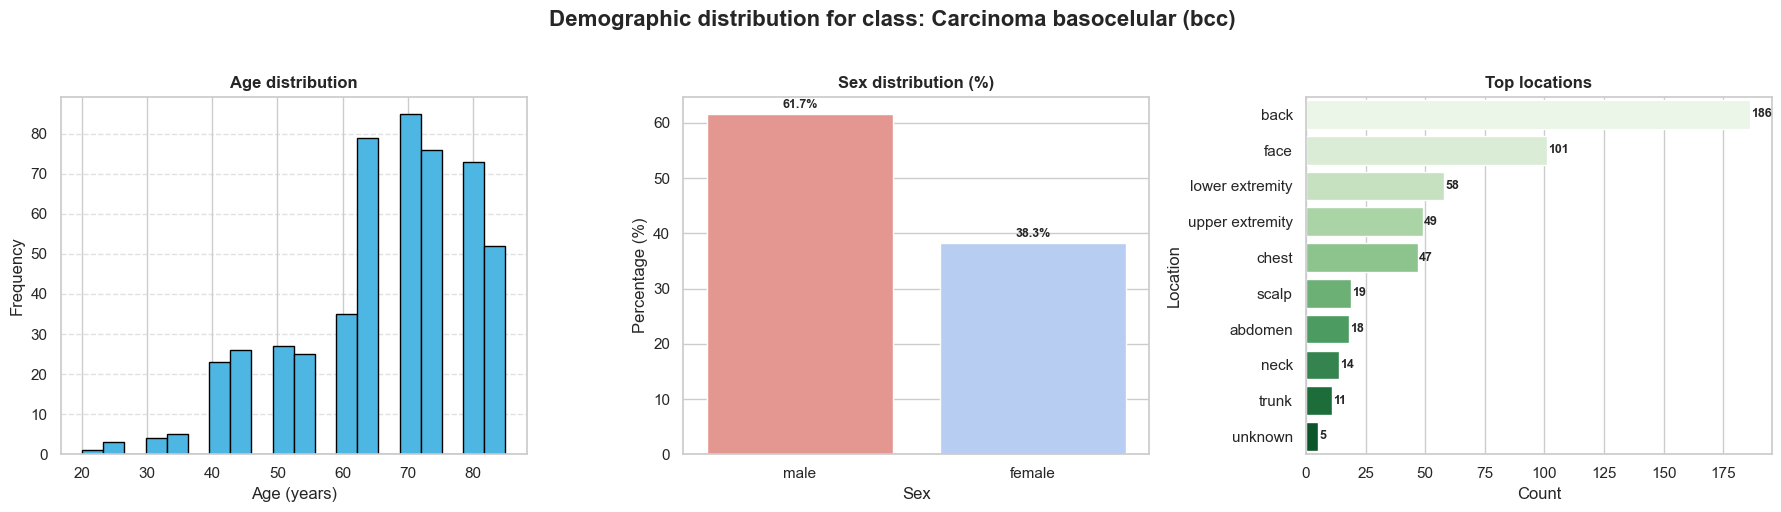

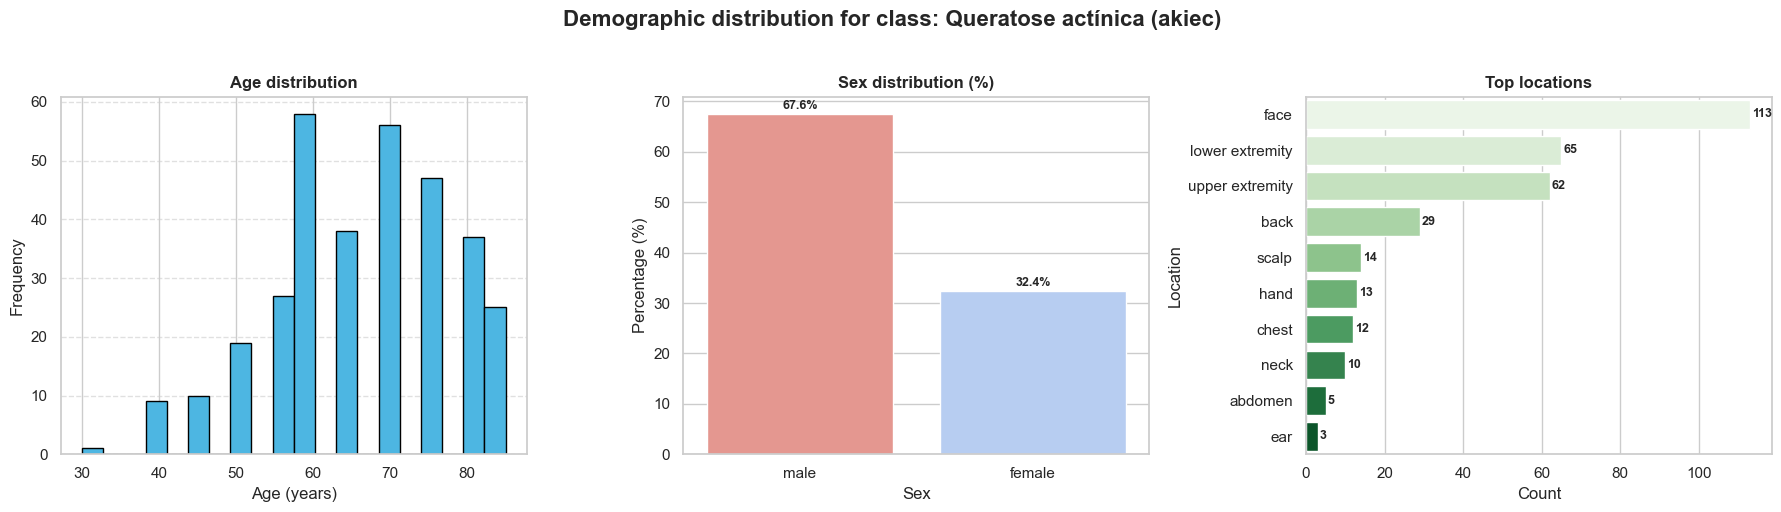

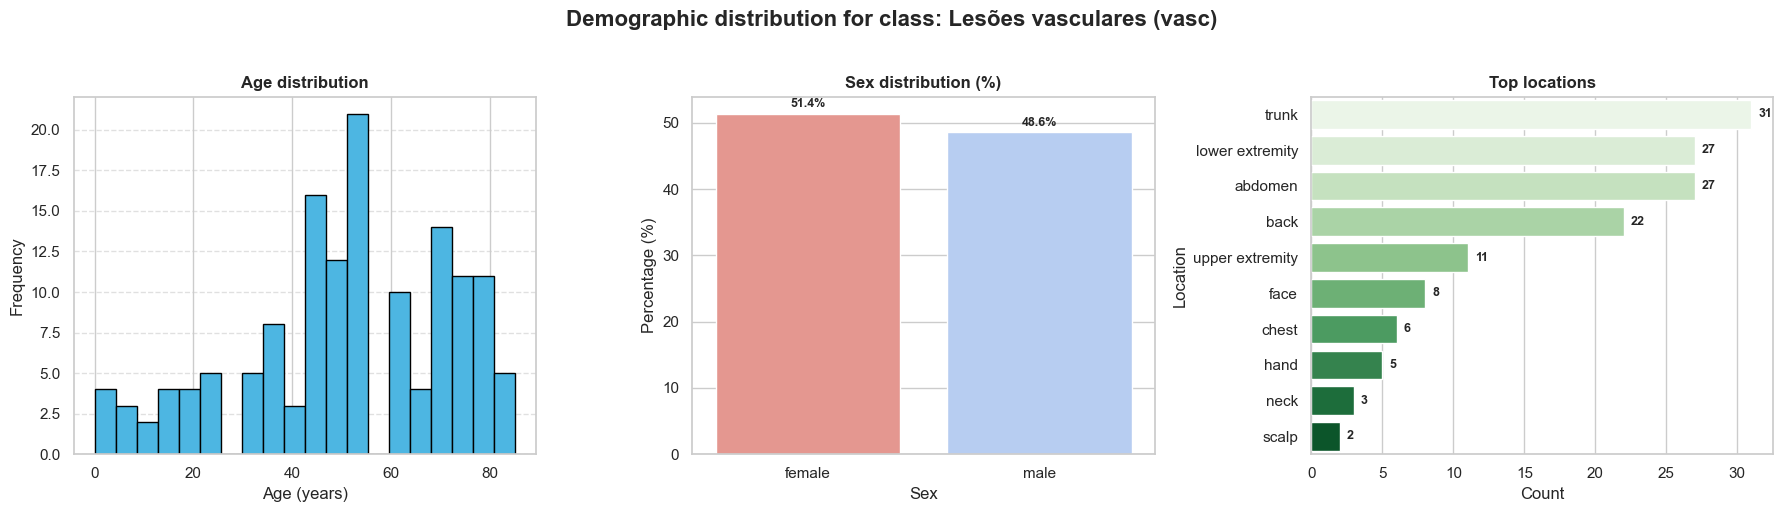

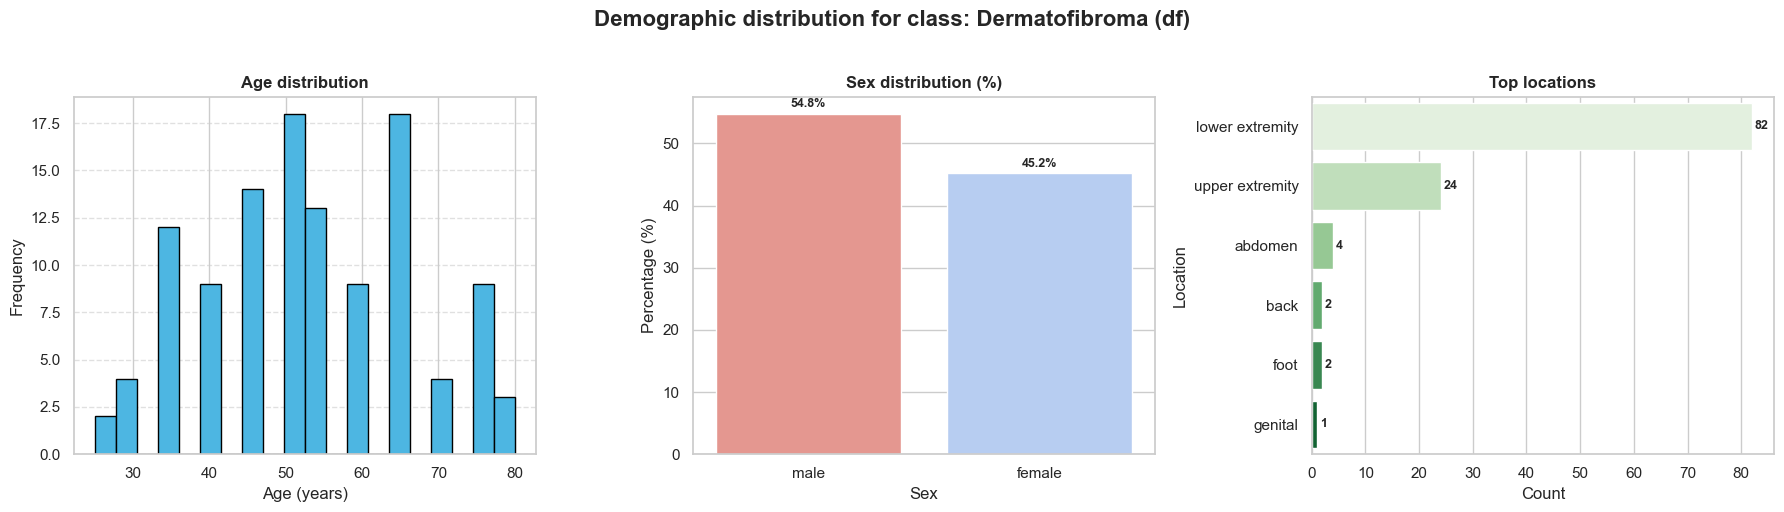

In [27]:
for cls in class_names: 
    plot_demographics_for_class(metadata_df, cls, class_names.get(cls, cls))

A função `plot_demographics_for_class` gera, para cada classe, gráficos com:

- histograma de idades;
- distribuição de sexo;
- distribuição das localizações anatômicas.

Essa análise **condicionada ao diagnóstico** ajuda a entender melhor o contexto clínico de cada classe:

- algumas lesões aparecem mais em determinadas faixas etárias;
- a proporção entre homens e mulheres pode variar entre diagnósticos;
- certas classes são mais comuns em regiões específicas do corpo (por exemplo, tronco/costas vs. extremidades).

Esses padrões mostram que os metadados trazem informação relevante e podem ser úteis em **modelos multimodais** (imagem + metadados).  
Ao mesmo tempo, evidenciam possíveis **vieses de amostragem**: se uma classe aparece quase sempre em uma região do corpo, o modelo pode aprender atalhos que não generalizam bem para outros cenários.

---

### 6. Análise das imagens

#### 6.1 Propriedades gerais das imagens

In [28]:
widths = []
heights = []
modes = []
formats = []
corrupted = []

for path in metadata_df["image_path"]:
    try:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
            formats.append(img.format)
    except:
        corrupted.append(path)

# Cria df com informações das imagens
img_info = pd.DataFrame({
    "width": widths,
    "height": heights,
    "mode": modes,
    "format": formats
})

print("Dimensões:")
print(img_info[["width", "height"]].describe(), "\n")

print("Modos de Cor:")
print(img_info["mode"].value_counts(), "\n")

print("Formatos das Imagens:")
print(img_info["format"].value_counts(), "\n")

if len(corrupted) > 0:
    print("⚠️ Imagens corrompidas encontradas:")
    for path in corrupted:
        print(" -", path)
else:
    print("Nenhuma imagem corrompida encontrada.")

Dimensões:
         width   height
count  10015.0  10015.0
mean     600.0    450.0
std        0.0      0.0
min      600.0    450.0
25%      600.0    450.0
50%      600.0    450.0
75%      600.0    450.0
max      600.0    450.0 

Modos de Cor:
mode
RGB    10015
Name: count, dtype: int64 

Formatos das Imagens:
format
JPEG    10015
Name: count, dtype: int64 

Nenhuma imagem corrompida encontrada.


A partir da coluna `image_path`, foram obtidos os dados:

- largura (`width`);
- altura (`height`);
- modo de cor (`mode`);
- formato (`format`).

No HAM10000, observa-se que:

- todas as imagens são **coloridas (RGB)**;
- possuem resolução aproximada de **600 × 450 pixels**;
- estão salvas, em geral, no formato **JPEG**.

Essa homogeneidade de tamanho e formato reduz o esforço de pré-processamento, pois permite definir uma etapa única de resize e normalização antes de alimentar a rede neural.

#### 6.2 Exemplos visuais por classe

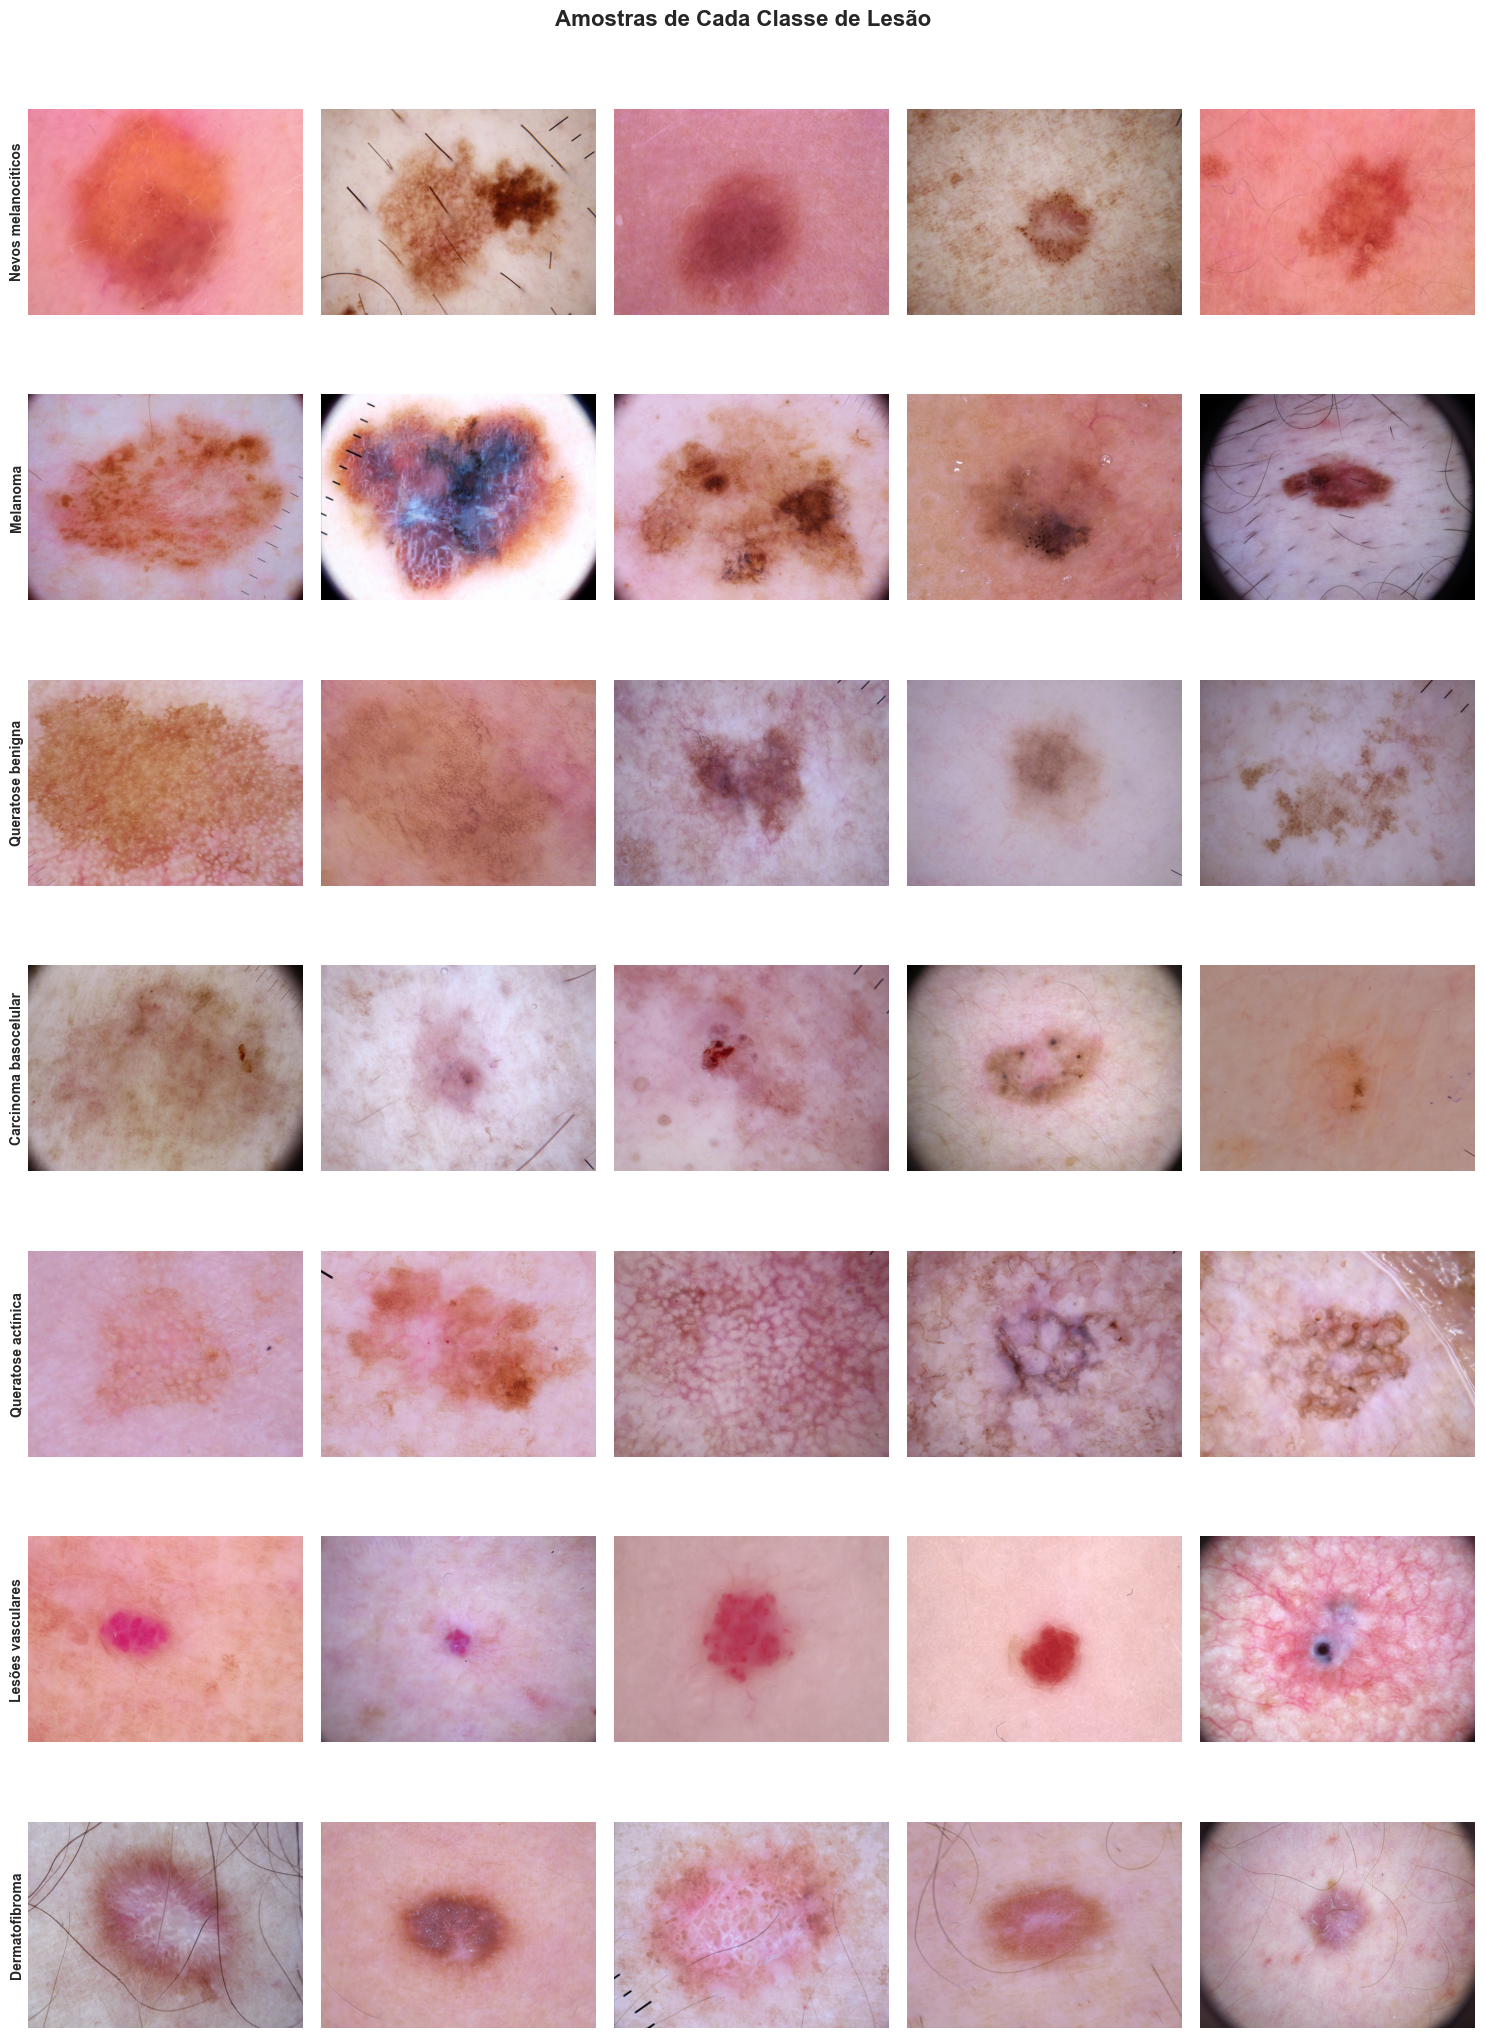

In [66]:
# Plotar 5 exemplos de cada classe
n_samples = 5
fig, axes = plt.subplots(num_classes, n_samples, figsize=(n_samples * 3, num_classes * 3))

for idx, (class_code, class_label) in enumerate(class_names.items()):
    # Pegar amostras aleatórias da classe
    class_df = metadata_df[metadata_df['dx'] == class_code]
    n_available = min(n_samples, len(class_df))
    class_samples = class_df.sample(n_available, random_state=SEED)
    
    for col, (_, row) in enumerate(class_samples.iterrows()):
        img = Image.open(row['image_path'])
        axes[idx, col].imshow(img)
        axes[idx, col].axis('off')
        
        # Adicionar título apenas na primeira coluna
        if col == 0:
            axes[idx, col].text(-10, img.size[1]//2, class_label, 
                              fontsize=10, fontweight='bold', 
                              rotation=90, va='center', ha='right')

plt.suptitle('Amostras de Cada Classe de Lesão', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

A partir das imagens é possível notar alguns padrões:

- lesões **vasculares (`vasc`)** tendem a apresentar coloração mais avermelhada e áreas bem delimitadas;
- **melanomas (`mel`)** costumam ser mais escuros, com bordas irregulares e variação de tonalidade dentro da mesma lesão;
- **dermatofibromas (`df`)** frequentemente exibem uma região central mais clara ou esbranquiçada;

---

## Preprocessamento

O objetivo desta etapa é transformar as imagens brutas do dataset em tensores normalizados e prontos para treinar a rede neural.

---

### Carregamento e Processamento de Imagem

In [29]:
print(f"Carregando e redimensionando {len(metadata_df)} imagens para {IMG_WIDTH}x{IMG_HEIGHT}...")
print("Isso pode levar alguns minutos...")

# Função para carregar e redimensionar imagem
def load_and_resize_image(path):
    try:
        img = Image.open(path)
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))
        return np.array(img)
    except Exception as e:
        print(f"Erro ao carregar {path}: {e}")
        return None

# Carregar imagens
metadata_df['image_array'] = metadata_df['image_path'].apply(load_and_resize_image)

# Remover imagens que falharam
metadata_df = metadata_df.dropna(subset=['image_array'])

print(f"{len(metadata_df)} imagens carregadas com sucesso!")


Carregando e redimensionando 10015 imagens para 128x128...
Isso pode levar alguns minutos...
10015 imagens carregadas com sucesso!


In [30]:
# Verificar distribuição de tamanhos
shapes = metadata_df['image_array'].apply(lambda x: x.shape).value_counts()
print("Distribuição de shapes:")
print(shapes)



Distribuição de shapes:
image_array
(128, 128, 3)    10015
Name: count, dtype: int64


As imagens são carregadas a partir dos caminhos presentes no `metadata_df['image_path']`. Cada imagem é:

- Aberta e convertida para RGB;

- Redimensionada para IMG_WIDTH x IMG_HEIGHT pixels;

- Convertida para um numpy.array do tipo float32.

---

### Train-Test Split

In [31]:
# Preparar features (X) e labels (y)
X = np.array(metadata_df['image_array'].tolist())
y = metadata_df['class_idx'].values

print("Shape dos dados:")
print(f"X: {X.shape}")
print(f"y: {y.shape}")


Shape dos dados:
X: (10015, 128, 128, 3)
y: (10015,)


A partir da coluna image_array, é construído o tensor de features:

- `X`: tensor de formato (N, 128, 128, 3), onde N é o número de imagens.

Os rótulos numéricos das classes são obtidos de `metadata_df['class_idx']`:

- `y`: vetor de tamanho N contendo o índice da classe de cada imagem.

Essa é a base para a divisão em treino, validação e teste.

In [32]:
# Primeira divisão: Train e Test 
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=SEED,
    stratify=y
)

val_relative_size = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=val_relative_size,
    random_state=SEED,
    stratify=y_train_full
)
print("Divisão dos dados:")
print(f"    Treino:     {X_train.shape[0]:5d} imagens ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"    Validação:  {X_val.shape[0]:5d} imagens ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"    Teste:      {X_test.shape[0]:5d} imagens ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"    TOTAL:      {len(X):5d} imagens")


Divisão dos dados:
    Treino:      7009 imagens (70.0%)
    Validação:   1503 imagens (15.0%)
    Teste:       1503 imagens (15.0%)
    TOTAL:      10015 imagens


Os dados são divididos em três subconjuntos, mantendo a proporção original das classes (estratificação):

- Treino: 70% das imagens

- Validação: 15% das imagens

- Teste: 15% das imagens

A divisão é feita em duas etapas:

- Separação inicial de teste a partir do conjunto completo;

- Divisão do restante entre treino e validação, usando uma fração relativa (para manter as porcentagens desejadas).

---

### Padronização

In [33]:
# Calcular média e desvio padrão do conjunto de treino
X_train_mean = np.mean(X_train)
X_train_std = np.std(X_train)

print("Conjunto de treino (antes da normalização):")
print(f"Média: {X_train_mean:.2f}")
print(f"Desvio padrão: {X_train_std:.2f}")
print(f"Min: {X_train.min()}")
print(f"Max: {X_train.max()}")

# Padronização (z-score)
X_train = (X_train - X_train_mean) / X_train_std
X_val   = (X_val   - X_train_mean) / X_train_std
X_test  = (X_test  - X_train_mean) / X_train_std

print("Após normalização (padronização):")
print(f"Média: {X_train.mean():.6f}")
print(f"Desvio padrão: {X_train.std():.6f}")

Conjunto de treino (antes da normalização):
Média: 159.90
Desvio padrão: 46.65
Min: 0
Max: 255
Após normalização (padronização):
Média: -0.000000
Desvio padrão: 1.000000


A normalização é feita **apenas com base no conjunto de treino**, evitando vazamento de informação entre os conjuntos.

1. Calcula-se a **média** e o **desvio padrão** de todos os pixels de `X_train`.
2. Cada conjunto (`X_train`, `X_val`, `X_test`) é padronizado usando: $X' = \frac{X - \mu_{\text{train}}}{\sigma_{\text{train}}}$

Após a padronização:

* O conjunto de **treino** passa a ter média ≈ 0 e desvio padrão ≈ 1;
* Os conjuntos de **validação** e **teste** são transformados usando os mesmos parâmetros do treino.


---

### One-Hot Encoding Labels Numéricos

In [34]:
# One-hot encoding
y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_val_encoded = to_categorical(y_val, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

print("Exemplo de encoding:")
print(f"   Label original: {y_train[0]}")
print(f"   One-hot encoded: {y_train_encoded[0]}")

Exemplo de encoding:
   Label original: 5
   One-hot encoded: [0. 0. 0. 0. 0. 1. 0.]


Os rótulos numéricos (`y_train`, `y_val`, `y_test`) são convertidos para vetores *one-hot* utilizando `num_classes` como dimensão:

* `y_train_encoded`
* `y_val_encoded`
* `y_test_encoded`


---

## Módulos

Os módulos são trechos de códigos utilizados para o proccessamento, treinamento e demonstração dos dados.

### Redes Neurais Convolucionais (CNNs)

### Visual Transformer

### Gráficos

## Modelo Dummy

## Implementação CNNs

### CNN Simples

### CNN com Pesos

### CNN com Augmentation

### CNN com Metadata

### Fine-Tuning CNN (Modelo XXXX)

### Resultados

## Implementação Visual Transformer

### Visual Transformer

### Fine-Tuning Visual Transformer (Modelo XXXX)

### Resultados

## Comparação

## Conclusão